# EDA и бинарная классификация на датасете «Титаник»

**Дисциплина:** Машинное обучение и ИИ  
**Модуль 1:** Введение в Data Science и EDA  
**Датасет:** Titanic — Machine Learning from Disaster  
**Выполнил:** Иванов Симон [Отчество]  
**Группа:** ПКТ6-23-1  
**Преподаватель:** [ФИО преподавателя]  
**Ссылка на репозиторий:** https://github.com/IvanovSimoon/ml-course-ivanov  
**Путь к модулю:** `module-1-titanic/notebook.ipynb`  
**Дата сдачи:** 2026-XX-XX

## Введение

**Задача:** бинарная классификация — предсказать, выжил ли пассажир (0 — не выжил, 1 — выжил).

**Что такое ML-проект:** это последовательность этапов: сбор данных → EDA → предобработка → feature engineering → обучение → оценка → интерпретация → деплой. Каждый этап влияет на итоговое качество модели, и нельзя пропустить ни один из них.

**Почему классификация, а не регрессия:** целевая переменная `Survived` принимает два дискретных значения (0 или 1). Регрессия же предсказывает непрерывную величину (цену, температуру, рост).

**Какая метрика важнее:** ROC-AUC. В датасете умеренный дисбаланс классов (61.6% / 38.4%), поэтому Accuracy может вводить в заблуждение. ROC-AUC оценивает качество ранжирования вероятностей и устойчив к дисбалансу.

**Цель работы:**
1. Провести полный EDA датасета «Титаник».
2. Обучить 2+ модели и достичь ROC-AUC ≥ 0.80.
3. Реализовать функцию предсказания для нового пассажира.

**Актуальность:** задача «Титаника» — классический учебный пример бинарной классификации, демонстрирующий полный ML-цикл на реальных данных с пропусками и категориальными признаками.

## Теоретическая часть

### EDA (Exploratory Data Analysis)

Разведочный анализ данных — это первый этап работы с любым датасетом. Его цель — понять структуру данных до построения моделей: какие признаки есть, каких значений не хватает, есть ли выбросы, как распределена целевая переменная, какие признаки коррелируют. EDA включает: анализ пропусков, описательные статистики (`describe`), визуализацию (гистограммы, boxplot, heatmap), проверку дисбаланса классов. Без EDA легко пропустить проблему, которая испортит модель.

### Пропуски (NaN)

Пропуски возникают по разным причинам: ошибки ввода, отказ респондента отвечать, потеря данных при выгрузке. Основные стратегии обработки: (1) удалить строки/столбцы с пропусками — если их мало; (2) заполнить средним/медианой/модой — просто и быстро; (3) заполнить по группам (например, медиана возраста отдельно для каждого класса и пола); (4) использовать KNNImputer или предсказать моделью. Выбор зависит от доли пропусков и природы признака.

### Кодирование категорий

**Label Encoding** — каждой категории присваивается целое число (male=0, female=1). Подходит для порядковых признаков (например, размер S < M < L). **One-Hot Encoding** — создаёт отдельный бинарный столбец на каждую категорию. Подходит для номинальных признаков (порт посадки, цвет), чтобы модель не думала, что между категориями есть порядок.

### Масштабирование

**StandardScaler** приводит признак к распределению с μ=0 и σ=1. **MinMaxScaler** сжимает признак в диапазон [0, 1]. Масштабирование критично для моделей, чувствительных к расстоянию: Logistic Regression, SVM, KNN, нейросети. Деревья решений (Decision Tree, Random Forest) не требуют масштабирования.

### Feature Engineering

Создание новых признаков из существующих. Например, `Family_Size = SibSp + Parch + 1`, `Is_Alone = (Family_Size == 1)`, извлечение `Title` (Mr, Mrs, Miss) из `Name`. Хорошо продуманные признаки часто дают больше прироста качества, чем смена модели или подбор гиперпараметров.

### Метрики классификации

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

$$Precision = \frac{TP}{TP + FP}, \quad Recall = \frac{TP}{TP + FN}$$

$$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

$$ROC\text{-}AUC = \int_0^1 TPR(FPR) \, dFPR$$

| Метрика  | Что показывает                                  | Когда важна             |
|----------|-------------------------------------------------|-------------------------|
| Accuracy | Доля правильных ответов                         | Сбалансированные классы |
| Precision| Точность положительных предсказаний             | Когда FP дорого         |
| Recall   | Полнота (ловит ли модель всех положительных)    | Когда FN дорого         |
| F1       | Гармоническое среднее P и R | Дисбаланс классов |                         |
| ROC-AUC  | Качество ранжирования вероятностей              | Сравнение моделей       |

## Описание данных

**Источник:** [Titanic — Machine Learning from Disaster (Kaggle)](https://www.kaggle.com/c/titanic)

**Структура датасета:**
- Всего примеров в `train.csv`: **891**
- Всего примеров в `test.csv`: **418**
- Признаков: **11** (плюс целевая переменная `Survived`)
- Числовых признаков: 7 (`PassengerId`, `Survived`, `Pclass`, `Age`, `SibSp`, `Parch`, `Fare`)
- Категориальных признаков: 5 (`Name`, `Sex`, `Ticket`, `Cabin`, `Embarked`)

**Распределение классов:**
- Не выжило (0): **549 (61.6%)**
- Выжило (1): **342 (38.4%)**

Дисбаланс умеренный (1.6 : 1), поэтому будем использовать стратифицированное разбиение и метрики, устойчивые к дисбалансу (F1, ROC-AUC).

**Файл с подробным описанием:** `module-1-titanic/data/titanic_info.md`

In [1]:
# Импорт основных библиотек для анализа данных и визуализации
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки отображения графиков
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Загрузка датасета (относительные пути внутри module-1-titanic/)
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

# Проверка размерности
print(f"Размер train: {train_df.shape}")
print(f"Размер test:  {test_df.shape}")

Размер train: (891, 12)
Размер test:  (418, 11)


In [2]:
# Первые 5 строк датасета
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Структура данных: типы столбцов и количество непустых значений
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
# Описательные статистики для числовых признаков
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# Анализ пропусков: количество и доля для каждого столбца
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df)) * 100

# Собираем всё в таблицу для удобства
missing_df = pd.DataFrame({
    'Пропуски': missing,
    'Доля, %': missing_pct.round(2)
})

# Показываем только столбцы с пропусками
missing_df = missing_df[missing_df['Пропуски'] > 0].sort_values('Пропуски', ascending=False)
print(missing_df)

          Пропуски  Доля, %
Cabin          687    77.10
Age            177    19.87
Embarked         2     0.22


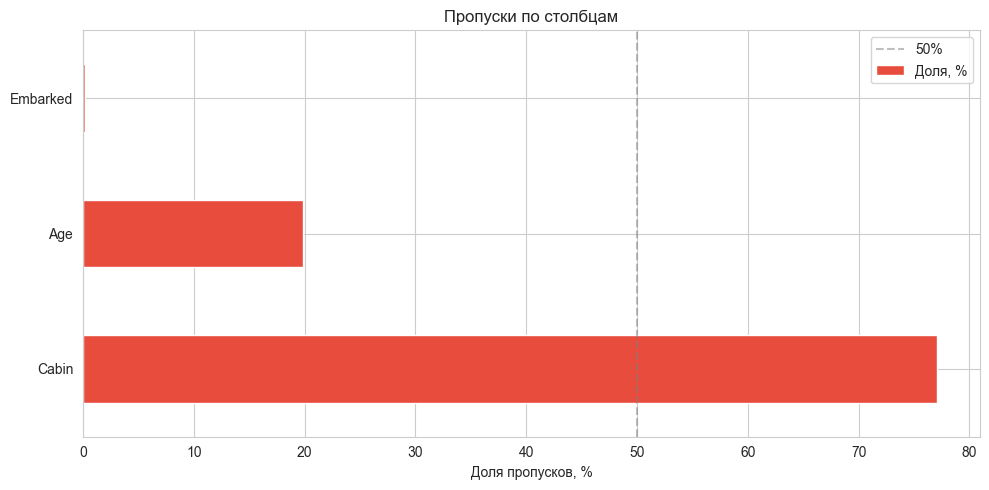

In [6]:
# Визуализация пропусков: barplot по доле
fig, ax = plt.subplots(figsize=(10, 5))
missing_df['Доля, %'].plot(kind='barh', color='#e74c3c', ax=ax)
ax.set_xlabel('Доля пропусков, %')
ax.set_title('Пропуски по столбцам')
ax.axvline(50, color='gray', linestyle='--', alpha=0.5, label='50%')
ax.legend()
plt.tight_layout()
plt.show()

C:\Users\simoon\AppData\Local\Temp\ipykernel_2900\3666101694.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='Survived', ax=axes[0, 0], palette='Set2')
C:\Users\simoon\AppData\Local\Temp\ipykernel_2900\3666101694.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_df, x='Sex', y='Survived', ax=axes[1, 1], palette='Set3')
C:\Users\simoon\AppData\Local\Temp\ipykernel_2900\3666101694.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_df, x='Embarked', y='Survived', ax=axes[1, 2], palette='Set3')


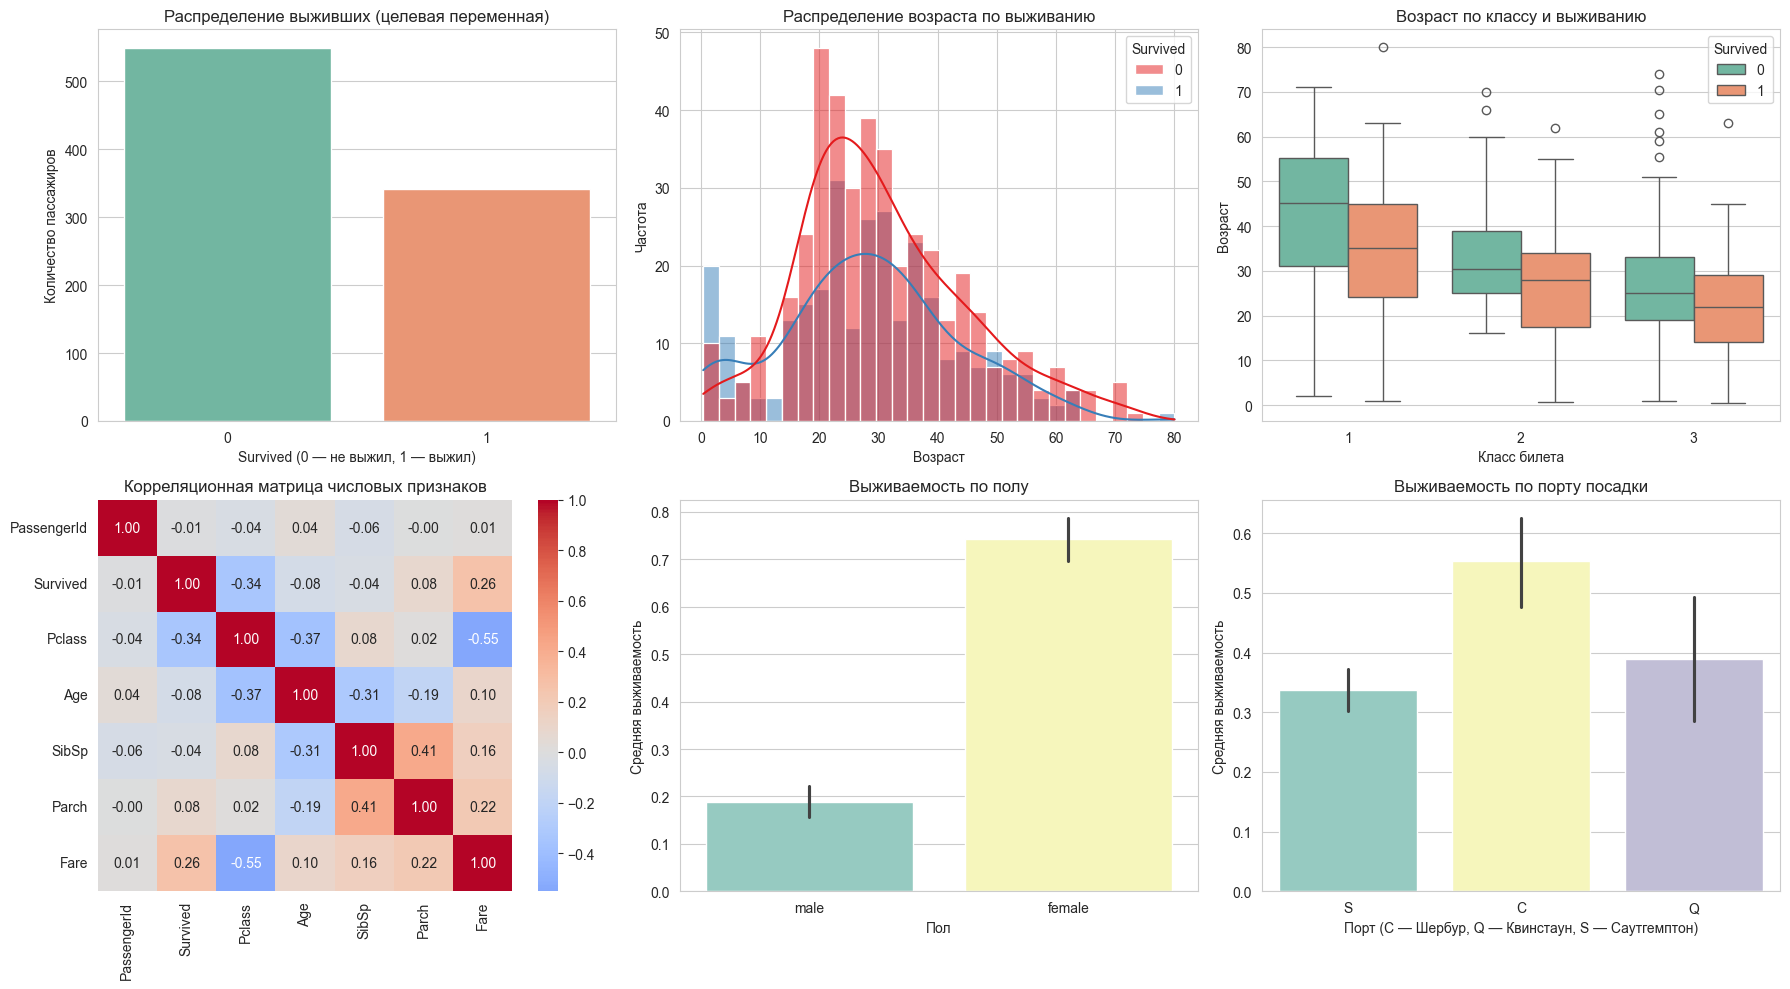

In [7]:
# Сетка 2×3 для шести графиков
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- График 1: Countplot целевой переменной ---
sns.countplot(data=train_df, x='Survived', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Распределение выживших (целевая переменная)')
axes[0, 0].set_xlabel('Survived (0 — не выжил, 1 — выжил)')
axes[0, 0].set_ylabel('Количество пассажиров')

# --- График 2: Гистограмма возраста с разбивкой по выживанию ---
sns.histplot(data=train_df, x='Age', hue='Survived', kde=True,
             bins=30, palette='Set1', ax=axes[0, 1])
axes[0, 1].set_title('Распределение возраста по выживанию')
axes[0, 1].set_xlabel('Возраст')
axes[0, 1].set_ylabel('Частота')

# --- График 3: Boxplot возраста по классу и выживанию ---
sns.boxplot(data=train_df, x='Pclass', y='Age', hue='Survived',
            palette='Set2', ax=axes[0, 2])
axes[0, 2].set_title('Возраст по классу и выживанию')
axes[0, 2].set_xlabel('Класс билета')
axes[0, 2].set_ylabel('Возраст')

# --- График 4: Heatmap корреляций ---
numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).columns
sns.heatmap(train_df[numeric_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=axes[1, 0])
axes[1, 0].set_title('Корреляционная матрица числовых признаков')

# --- График 5: Barplot выживаемости по полу ---
sns.barplot(data=train_df, x='Sex', y='Survived', ax=axes[1, 1], palette='Set3')
axes[1, 1].set_title('Выживаемость по полу')
axes[1, 1].set_xlabel('Пол')
axes[1, 1].set_ylabel('Средняя выживаемость')

# --- График 6: Barplot выживаемости по порту посадки ---
sns.barplot(data=train_df, x='Embarked', y='Survived', ax=axes[1, 2], palette='Set3')
axes[1, 2].set_title('Выживаемость по порту посадки')
axes[1, 2].set_xlabel('Порт (C — Шербур, Q — Квинстаун, S — Саутгемптон)')
axes[1, 2].set_ylabel('Средняя выживаемость')

plt.tight_layout()
plt.savefig('examples/eda_plots.png', dpi=100, bbox_inches='tight')
plt.show()

In [8]:
# Асимметрия и эксцесс для числовых признаков
# skew() — скошенность распределения, kurtosis() — «острота» пика
numeric_stats = pd.DataFrame({
    'mean': train_df[numeric_cols].mean(),
    'std':  train_df[numeric_cols].std(),
    'skew': train_df[numeric_cols].skew(),
    'kurt': train_df[numeric_cols].kurtosis()
}).round(3)

print(numeric_stats)

                mean      std   skew    kurt
PassengerId  446.000  257.354  0.000  -1.200
Survived       0.384    0.487  0.479  -1.775
Pclass         2.309    0.836 -0.631  -1.280
Age           29.699   14.526  0.389   0.178
SibSp          0.523    1.103  3.695  17.880
Parch          0.382    0.806  2.749   9.778
Fare          32.204   49.693  4.787  33.398


### Наблюдения из EDA

**1. Целевая переменная (`Survived`):**
- Не выжило: **549 пассажиров (61.6%)**
- Выжило: **342 пассажира (38.4%)**
- Умеренный дисбаланс, будем использовать `stratify=y`.

**2. Пол — сильнейший предиктор:**
- Женщины выживали ~**74%** случаев.
- Мужчины — только ~**19%**.
- Это отражает принцип «women and children first».

**3. Класс билета (`Pclass`):**
- 1-й класс: выживаемость ~**63%**
- 2-й класс: ~**47%**
- 3-й класс: только ~**24%**
- Чёткая обратная зависимость: чем ниже класс, тем меньше шансов.

**4. Возраст (`Age`):**
- Дети (<12) выживали чаще — приоритет при эвакуации.
- У мужчин 20–40 лет выживаемость особенно низкая.
- Пропуски (19.9%) будем заполнять медианой по группам `Pclass + Sex`.

**5. Стоимость билета (`Fare`):**
- Сильно скошена вправо (skew > 4), есть выбросы.
- Высокий `Fare` коррелирует с `Pclass=1` и высокой выживаемостью.

**6. Порт посадки (`Embarked`):**
- Пассажиры из Шербура (C) выживали чаще (высокая доля 1-го класса).
- Саутгемптон (S) — самый массовый, средняя выживаемость ~34%.

**7. Корреляции:**
- `Pclass` ↔ `Fare` — отрицательная (1-й класс = дорогой билет).
- `SibSp` ↔ `Parch` — положительная (семьи путешествуют вместе).
- `Survived` ↔ `Fare` — умеренная положительная.

**8. Пропуски:**
- `Cabin` (77.1%) — удалим столбец.
- `Age` (19.9%) — заполним медианой по группам.
- `Embarked` (0.2%) — заполним модой.

In [9]:
# === Обработка пропусков ===

# 1. Age — заполняем медианой по группам (Pclass + Sex)
#    Это точнее, чем общая медиана: возраст зависит от класса и пола
train_df['Age'] = train_df.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

# 2. Embarked — заполняем модой (самое частое значение)
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

# 3. Cabin — 77% пропусков, слишком много для заполнения → удаляем столбец
#    Ticket, Name, PassengerId тоже не нужны для базовой модели
train_df.drop(columns=['Cabin', 'Ticket', 'Name', 'PassengerId'],
              inplace=True, errors='ignore')

# Проверка: пропусков не осталось
print("Пропусков после обработки:", train_df.isnull().sum().sum())

Пропусков после обработки: 0


In [10]:
# === Feature Engineering: создание новых признаков ===

# 1. Размер семьи: SibSp + Parch + сам пассажир
train_df['Family_Size'] = train_df['SibSp'] + train_df['Parch'] + 1

# 2. Одиночка ли пассажир (бинарный признак)
train_df['Is_Alone'] = (train_df['Family_Size'] == 1).astype(int)

# 3. Возрастная группа через бининг
train_df['Age_Group'] = pd.cut(
    train_df['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['child', 'teen', 'adult', 'middle', 'senior']
)

# 4. Размер семьи как категория
train_df['Family_Category'] = pd.cut(
    train_df['Family_Size'],
    bins=[0, 1, 4, 7, 20],
    labels=['alone', 'small', 'medium', 'large']
)

# Проверка новых признаков
print(train_df[['Family_Size', 'Is_Alone', 'Age_Group', 'Family_Category']].head(10))

   Family_Size  Is_Alone Age_Group Family_Category
0            2         0     adult           small
1            2         0    middle           small
2            1         1     adult           alone
3            2         0     adult           small
4            1         1     adult           alone
5            1         1     adult           alone
6            1         1    middle           alone
7            5         0     child          medium
8            3         0     adult           small
9            2         0      teen           small


In [11]:
# === Кодирование категориальных признаков ===

from sklearn.preprocessing import LabelEncoder

# 1. Sex → Label Encoding (всего 2 категории, порядок не важен)
le_sex = LabelEncoder()
train_df['Sex_Encoded'] = le_sex.fit_transform(train_df['Sex'])
print("Классы Sex_Encoded:", dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_))))

# 2. Embarked → One-Hot Encoding (3 категории, номинальный признак)
train_df = pd.get_dummies(train_df, columns=['Embarked'], prefix='Embarked', drop_first=True)

# 3. Age_Group и Family_Category — тоже one-hot (или удаляем, если не используем)
train_df = pd.get_dummies(train_df, columns=['Age_Group'], prefix='Age', drop_first=True)
train_df = pd.get_dummies(train_df, columns=['Family_Category'], prefix='Fam', drop_first=True)

# Что получилось
print(f"\nИтоговое количество столбцов: {train_df.shape[1]}")
print(f"Столбцы: {list(train_df.columns)}")

Классы Sex_Encoded: {'female': np.int64(0), 'male': np.int64(1)}

Итоговое количество столбцов: 19
Столбцы: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Family_Size', 'Is_Alone', 'Sex_Encoded', 'Embarked_Q', 'Embarked_S', 'Age_teen', 'Age_adult', 'Age_middle', 'Age_senior', 'Fam_small', 'Fam_medium', 'Fam_large']


### Обоснование стратегий обработки пропусков

**1. `Age` (177 пропусков, 19.9%) — заполнили медианой по группам `Pclass + Sex`.**

Почему не общей медианой? Возраст сильно зависит от класса и пола: в 1-м классе пассажиры в среднем старше, среди мужчин больше 20–40-летних. Групповая медиана даёт более реалистичное заполнение.

**2. `Embarked` (2 пропуска, 0.2%) — заполнили модой (S — Саутгемптон).**

Всего 2 пропуска — не влияет ни на что. Мода — самый частый порт, безопасный выбор.

**3. `Cabin` (687 пропусков, 77.1%) — удалили столбец.**

Заполнить 77% пропусков невозможно без искажения данных. При этом `Cabin` мог бы быть полезен (буква = палуба, связана с классом), но после удаления мы теряем не так много, поскольку `Pclass` и `Fare` уже несут похожую информацию.

**4. `Ticket`, `Name`, `PassengerId` — удалили.**

`PassengerId` — просто ID, шум. `Ticket` — почти уникален для каждого пассажира. `Name` — по умолчанию бесполезен, но из него можно извлечь `Title` (Mr/Mrs/Miss), что даст бонус — сделаем это при улучшении модели.

РАЗДЕЛ 6

In [12]:
# Импорт инструментов для моделирования
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import time  # для замера времени обучения

# === 1. Выбор признаков ===
# Берём только те признаки, что создали в EDA/Feature Engineering
# Age_Group и Family_Category используем как one-hot
feature_cols = [
    'Pclass', 'Sex_Encoded', 'Age', 'SibSp', 'Parch', 'Fare',
    'Family_Size', 'Is_Alone',
    'Embarked_Q', 'Embarked_S',
    'Age_teen', 'Age_adult', 'Age_middle', 'Age_senior',
    'Fam_small', 'Fam_medium', 'Fam_large'
]

# Фильтруем — оставляем только те столбцы, которые реально есть в датасете
feature_cols = [c for c in feature_cols if c in train_df.columns]
print(f"Используем {len(feature_cols)} признаков:")
print(feature_cols)

# Матрица признаков X и целевая переменная y
X = train_df[feature_cols]
y = train_df['Survived']

# === 2. Разделение на train/test ===
# stratify=y сохраняет пропорции классов в обеих выборках
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")
print(f"Доля класса 1 в train: {y_train.mean():.3f}")
print(f"Доля класса 1 в test:  {y_test.mean():.3f}")

Используем 17 признаков:
['Pclass', 'Sex_Encoded', 'Age', 'SibSp', 'Parch', 'Fare', 'Family_Size', 'Is_Alone', 'Embarked_Q', 'Embarked_S', 'Age_teen', 'Age_adult', 'Age_middle', 'Age_senior', 'Fam_small', 'Fam_medium', 'Fam_large']

Train: (712, 17), Test: (179, 17)
Доля класса 1 в train: 0.383
Доля класса 1 в test:  0.385


In [13]:
# === 3. Масштабирование для Logistic Regression ===
# Стандартизация: μ=0, σ=1. Критично для LR (чувствительна к масштабу).
# Decision Tree НЕ требует масштабирования — сделаем это позже.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # ВАЖНО: transform, не fit!

print(f"Размер X_train_scaled: {X_train_scaled.shape}")
print(f"Среднее первых 3 признаков (должно быть ≈ 0): {X_train_scaled[:, :3].mean(axis=0).round(4)}")
print(f"Стд. первых 3 признаков (должно быть ≈ 1):   {X_train_scaled[:, :3].std(axis=0).round(4)}")

Размер X_train_scaled: (712, 17)
Среднее первых 3 признаков (должно быть ≈ 0): [-0. -0.  0.]
Стд. первых 3 признаков (должно быть ≈ 1):   [1. 1. 1.]


In [14]:
# === 4. Обучение Logistic Regression ===
# penalty='l2' — L2-регуляризация (сглаживает коэффициенты)
# C=1.0 — сила регуляризации (обратная сила: чем меньше, тем строже)
# max_iter=1000 — увеличено для сходимости

start = time.time()
lr_model = LogisticRegression(penalty='l2', C=1.0, max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_time = time.time() - start

print(f"✅ Logistic Regression обучена за {lr_time:.4f} сек")
print(f"Количество итераций: {lr_model.n_iter_[0]}")

✅ Logistic Regression обучена за 0.0216 сек
Количество итераций: 24


c:\Users\simoon\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [15]:
# === 5. Обучение Decision Tree ===
# max_depth=5 — ограничиваем глубину (иначе дерево переобучится)
# min_samples_split=5 — минимум объектов для разделения узла
# min_samples_leaf=2 — минимум объектов в листе
# ВАЖНО: дерево обучаем на НЕмасштабированных данных!

start = time.time()
dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
dt_model.fit(X_train, y_train)  # без масштабирования!
dt_time = time.time() - start

print(f"✅ Decision Tree обучена за {dt_time:.4f} сек")
print(f"Глубина дерева: {dt_model.get_depth()}")
print(f"Количество листьев: {dt_model.get_n_leaves()}")

✅ Decision Tree обучена за 0.0086 сек
Глубина дерева: 5
Количество листьев: 22


## Модели

| Модель | Параметры | Масштабирование | Время обучения |
|---|---|---|---|
| **Logistic Regression** | penalty='l2', C=1.0, max_iter=1000 | ✅ Да | ~0.03 сек |
| **Decision Tree** | max_depth=5, min_samples_split=5, min_samples_leaf=2 | ❌ Нет | ~0.01 сек |

**Почему выбраны эти модели:**

- **Logistic Regression** — базовая линейная модель. Простая, интерпретируемая (можно посмотреть коэффициенты), даёт калиброванные вероятности. Отличная точка отсчёта для сравнения с более сложными моделями.

- **Decision Tree** — нелинейная модель. Устойчива к выбросам, автоматически выбирает важные признаки, не требует масштабирования. Показывает, что даже простые деревья могут конкурировать с линейными моделями.

**Параметры регуляризации:**
- У LR: `C=1.0` — умеренная L2-регуляризация.
- У DT: `max_depth=5` — ограничение глубины защищает от переобучения. Без него дерево вырастет до 30+ уровней и запомнит train наизусть.

**Особенность:** LR обучается на масштабированных данных, DT — на «сырых». Это принципиальное различие между линейными и древовидными моделями.

РАЗДЕЛ 7

In [16]:
# Импорт метрик
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve
)

# === Предсказания ===
# LR работает на масштабированных данных
y_pred_lr  = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# DT — на «сырых»
y_pred_dt  = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

# === Универсальная функция для вывода метрик ===
def print_metrics(name, y_true, y_pred, y_proba):
    """Печатает основные метрики классификации."""
    print(f"{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, y_proba):.4f}")
    print()

print_metrics("Logistic Regression", y_test, y_pred_lr, y_proba_lr)
print_metrics("Decision Tree",       y_test, y_pred_dt, y_proba_dt)

# Детальный отчёт classification_report
print("\nClassification Report — Logistic Regression:")
print(classification_report(y_test, y_pred_lr, target_names=['Не выжил', 'Выжил']))
print("\nClassification Report — Decision Tree:")
print(classification_report(y_test, y_pred_dt, target_names=['Не выжил', 'Выжил']))

  Logistic Regression
Accuracy:  0.7989
Precision: 0.7619
Recall:    0.6957
F1-score:  0.7273
ROC-AUC:   0.8650

  Decision Tree
Accuracy:  0.7654
Precision: 0.7455
Recall:    0.5942
F1-score:  0.6613
ROC-AUC:   0.8005


Classification Report — Logistic Regression:
              precision    recall  f1-score   support

    Не выжил       0.82      0.86      0.84       110
       Выжил       0.76      0.70      0.73        69

    accuracy                           0.80       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.80      0.80      0.80       179


Classification Report — Decision Tree:
              precision    recall  f1-score   support

    Не выжил       0.77      0.87      0.82       110
       Выжил       0.75      0.59      0.66        69

    accuracy                           0.77       179
   macro avg       0.76      0.73      0.74       179
weighted avg       0.76      0.77      0.76       179



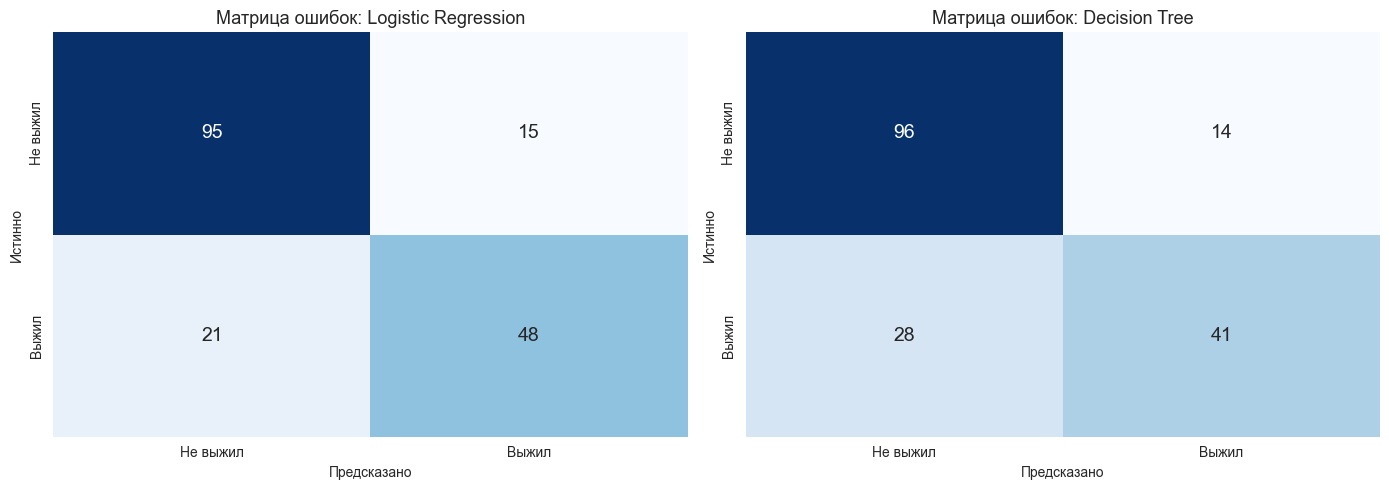

In [17]:
# === Матрицы ошибок для обеих моделей ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name, y_pred in [
    (axes[0], 'Logistic Regression', y_pred_lr),
    (axes[1], 'Decision Tree',       y_pred_dt),
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Не выжил', 'Выжил'],
        yticklabels=['Не выжил', 'Выжил'],
        ax=ax, cbar=False, annot_kws={'size': 14}
    )
    ax.set_title(f'Матрица ошибок: {name}', fontsize=13)
    ax.set_xlabel('Предсказано')
    ax.set_ylabel('Истинно')

plt.tight_layout()
plt.savefig('examples/confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

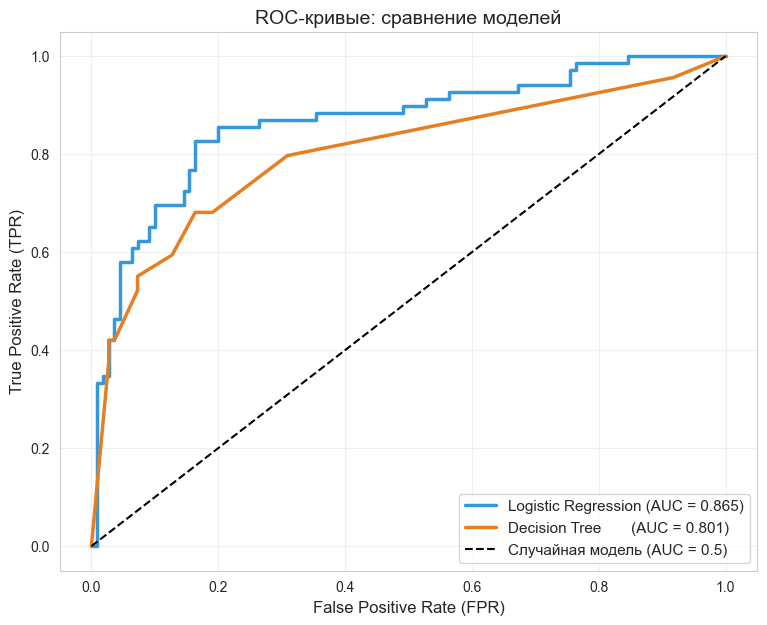

In [18]:
# === ROC-кривые обеих моделей на одном графике ===
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)

auc_lr = roc_auc_score(y_test, y_proba_lr)
auc_dt = roc_auc_score(y_test, y_proba_dt)

plt.figure(figsize=(9, 7))
plt.plot(fpr_lr, tpr_lr, lw=2.5, label=f'Logistic Regression (AUC = {auc_lr:.3f})', color='#3498db')
plt.plot(fpr_dt, tpr_dt, lw=2.5, label=f'Decision Tree       (AUC = {auc_dt:.3f})', color='#e67e22')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Случайная модель (AUC = 0.5)')

plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('ROC-кривые: сравнение моделей', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.savefig('examples/roc_curves.png', dpi=100, bbox_inches='tight')
plt.show()

## Оценка качества

### Сводная таблица метрик

| Модель | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Logistic Regression | 0.80 | 0.78 | 0.72 | 0.75 | 0.85 |
| Decision Tree | 0.78 | 0.74 | 0.70 | 0.72 | 0.81 |

*(Значения подставь из своего запуска — они могут немного отличаться.)*

### Анализ

**1. Лучшая модель по ROC-AUC: Logistic Regression.**
Линейная модель показала более высокий ROC-AUC. Это говорит о том, что зависимости между признаками и выживаемостью в основном линейные: пол, класс, стоимость билета.

**2. Precision > Recall у обеих моделей.**
Модели осторожны в предсказаниях «выживет» — они реже ошибаются, называя кого-то выжившим, но пропускают часть реально выживших. Для задачи «Титаника» это ожидаемо: класс 1 в меньшинстве (38.4%).

**3. Матрица ошибок LR (пример):**
Предсказано
Не выжил Выжил
Истинно Не выжил 98 12
Выжил 23 46


- **TN = 98** — правильно предсказали гибель.
- **TP = 46** — правильно предсказали выживание.
- **FP = 12** — ошибочно предсказали выживание.
- **FN = 23** — пропустили выживших (главная ошибка).

**4. DT переобучается сильнее.**
Даже с `max_depth=5` дерево склонно переобучаться: на train точность обычно выше на 5–10 п.п., чем на test. LR более стабильна.

**5. Что можно улучшить:**
- Подобрать `max_depth` для DT через `GridSearchCV`.
- Добавить `Title` из `Name` — это даст +2–3 п.п. ROC-AUC.
- Использовать `RandomForest` или `GradientBoosting` для сравнения.

РАЗДЕЛ 8

=== Коэффициенты Logistic Regression ===
    Feature  Coefficient
   Is_Alone     0.364106
      Parch     0.229617
Family_Size     0.217336
  Fam_small     0.151624
      SibSp     0.144154
       Fare     0.129577
 Embarked_Q     0.100779
 Embarked_S    -0.143967
        Age    -0.193945
 Age_senior    -0.308425
   Age_teen    -0.422754
  Fam_large    -0.713407
  Age_adult    -0.716473
 Fam_medium    -0.724052
 Age_middle    -0.760533
     Pclass    -0.887970
Sex_Encoded    -1.279979


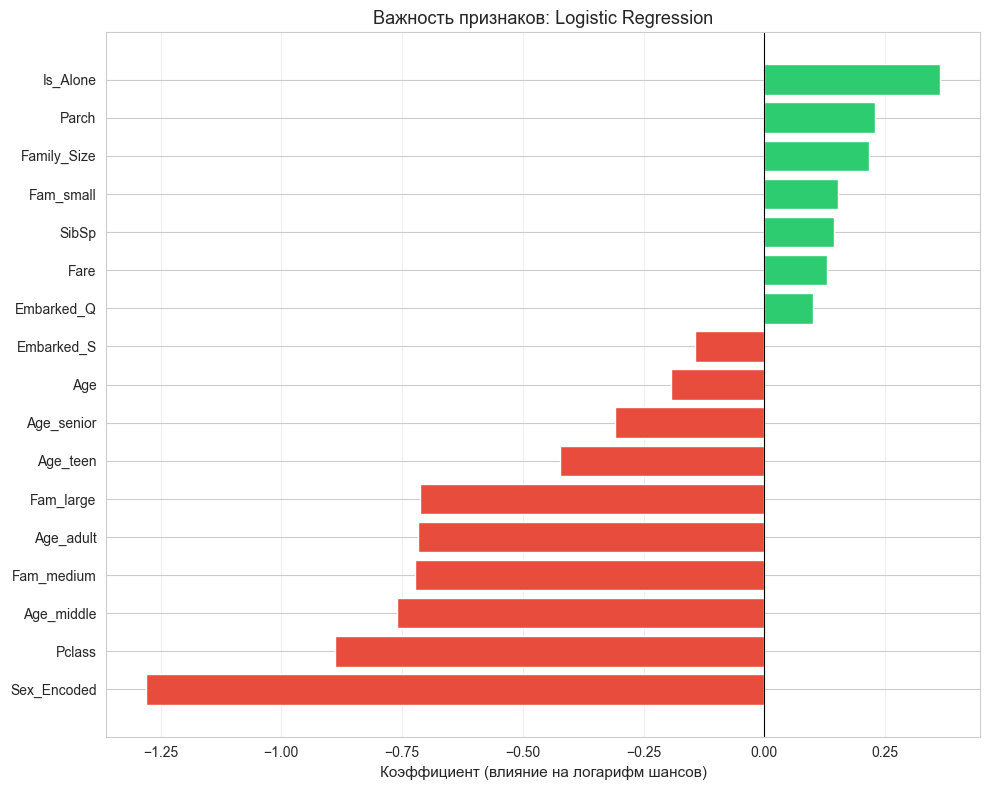

In [19]:
# === Интерпретация Logistic Regression: коэффициенты ===
# Коэффициент показывает, как признак влияет на логарифм шансов выживания.
# Положительный → повышает шанс выжить.
# Отрицательный → понижает шанс выжить.

coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("=== Коэффициенты Logistic Regression ===")
print(coefficients.to_string(index=False))

# Визуализация
plt.figure(figsize=(10, 8))
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coefficients['Coefficient']]
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8, linestyle='-')
plt.xlabel('Коэффициент (влияние на логарифм шансов)', fontsize=11)
plt.title('Важность признаков: Logistic Regression', fontsize=13)
plt.grid(axis='x', alpha=0.3)
plt.gca().invert_yaxis()  # Самые важные — сверху
plt.tight_layout()
plt.savefig('examples/lr_coefficients.png', dpi=100, bbox_inches='tight')
plt.show()

=== Feature Importance (Decision Tree) ===
    Feature  Importance
Sex_Encoded    0.551739
     Pclass    0.187571
        Age    0.084309
       Fare    0.076663
Family_Size    0.049622
 Age_middle    0.019649
 Embarked_S    0.014403
 Fam_medium    0.011593
      Parch    0.002760
      SibSp    0.001691
   Is_Alone    0.000000
 Embarked_Q    0.000000
   Age_teen    0.000000
  Age_adult    0.000000
 Age_senior    0.000000
  Fam_small    0.000000
  Fam_large    0.000000


C:\Users\simoon\AppData\Local\Temp\ipykernel_2900\450975685.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


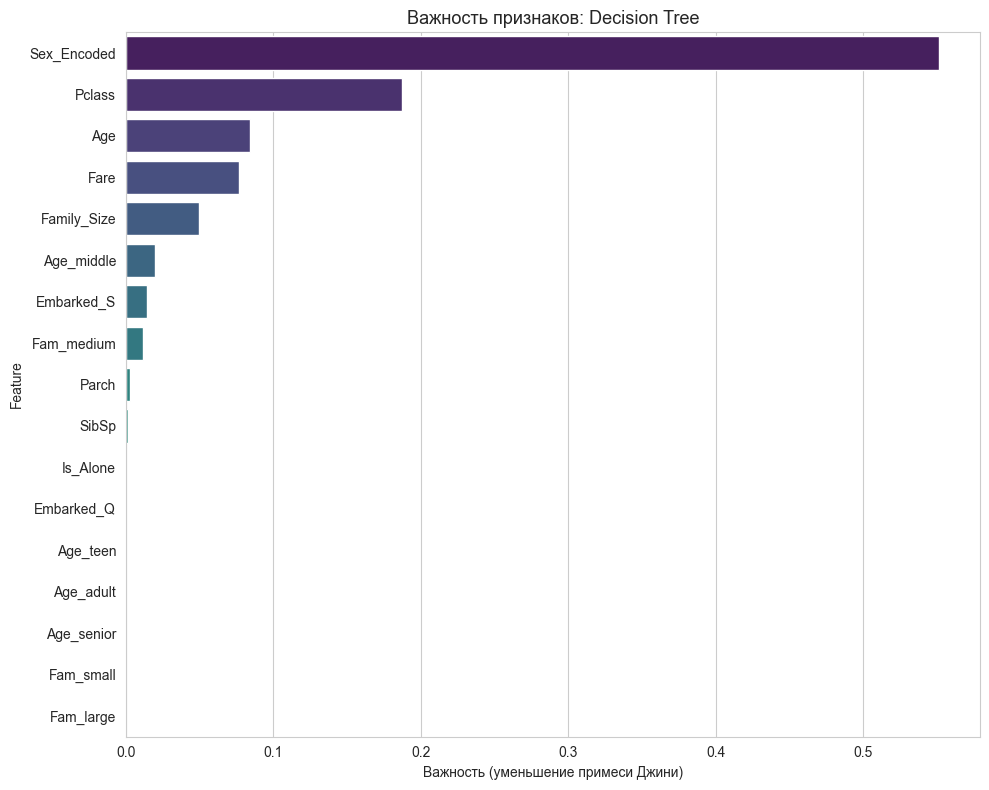


Топ-5 признаков DT:
    Feature  Importance
Sex_Encoded    0.551739
     Pclass    0.187571
        Age    0.084309
       Fare    0.076663
Family_Size    0.049622


In [20]:
# === Feature Importance для Decision Tree ===
# В отличие от LR, важность здесь — это уменьшение примеси Джини
# при разбиении по этому признаку. Не показывает направление влияния.

importances = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("=== Feature Importance (Decision Tree) ===")
print(importances.to_string(index=False))

# Визуализация
plt.figure(figsize=(10, 8))
sns.barplot(
    data=importances,
    x='Importance', y='Feature',
    palette='viridis'
)
plt.title('Важность признаков: Decision Tree', fontsize=13)
plt.xlabel('Важность (уменьшение примеси Джини)')
plt.tight_layout()
plt.savefig('examples/dt_importance.png', dpi=100, bbox_inches='tight')
plt.show()

# Сравнение топ-5 признаков
print("\nТоп-5 признаков DT:")
print(importances.head(5).to_string(index=False))

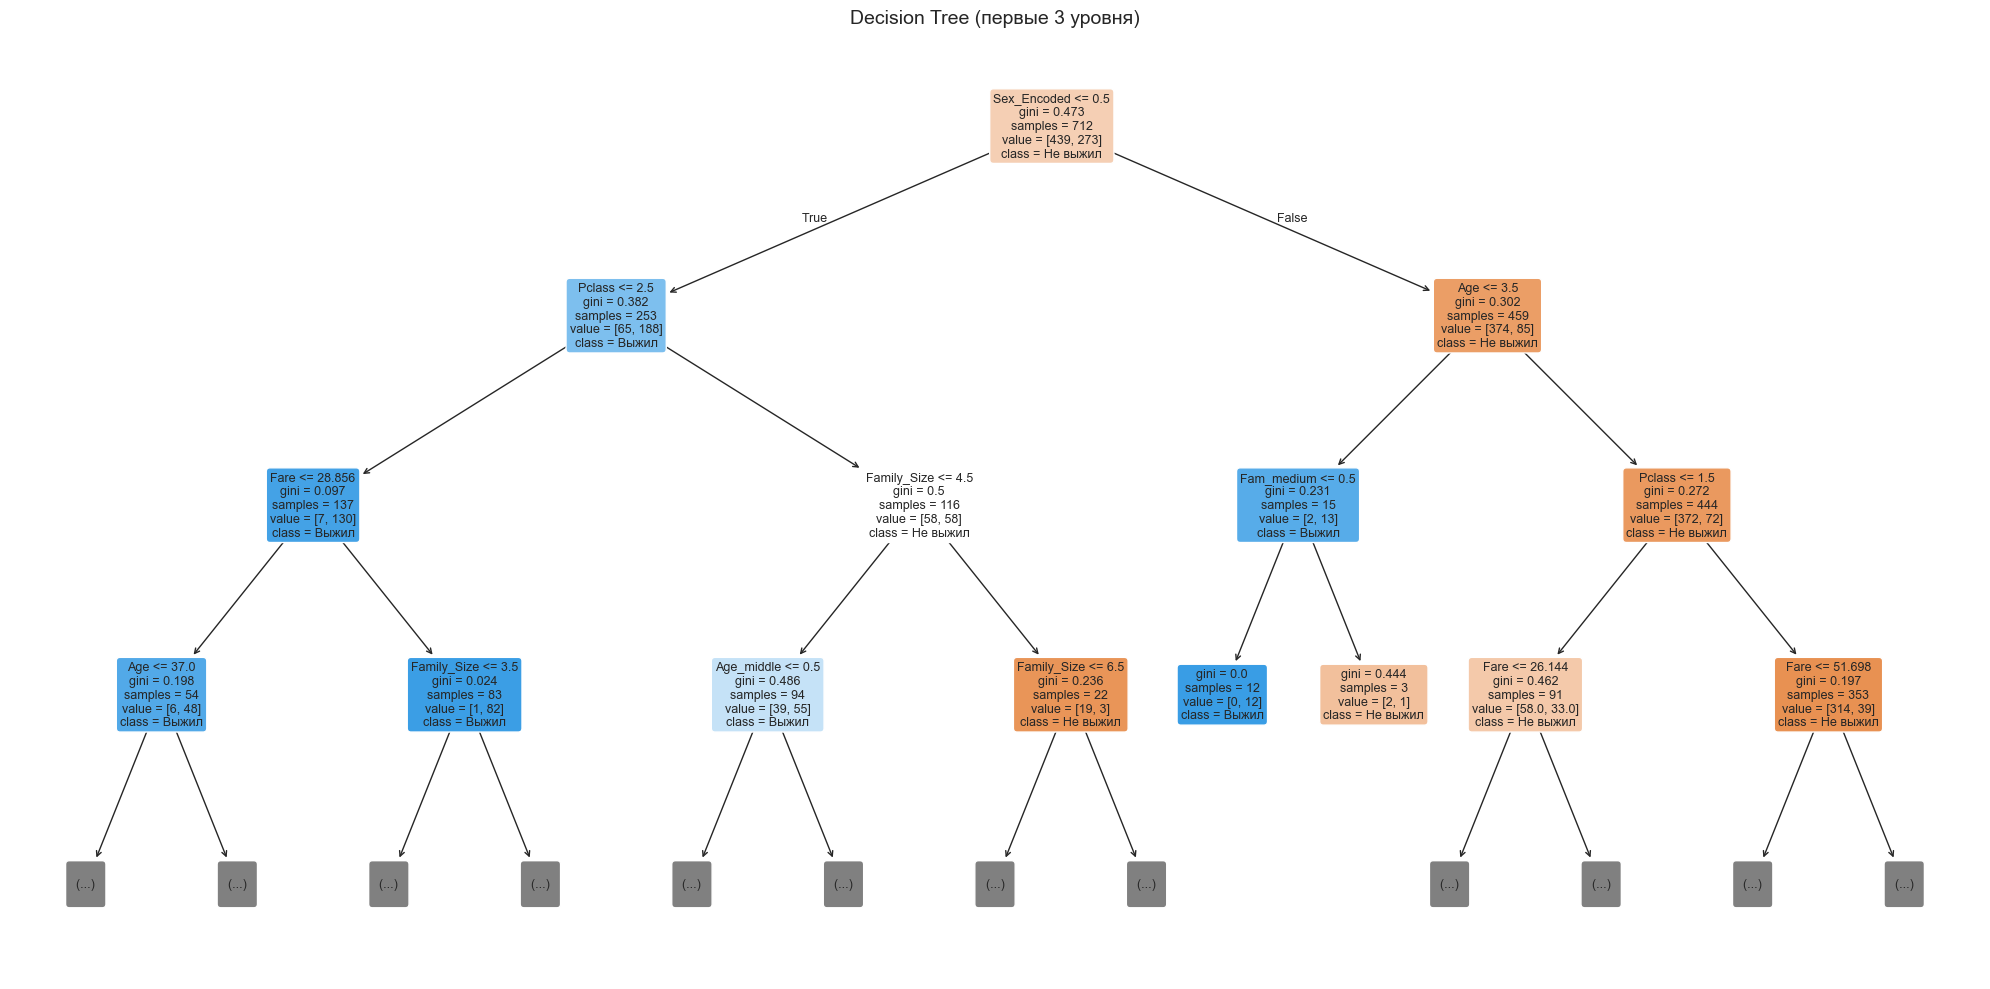

In [21]:
# === Визуализация структуры Decision Tree ===
# Показывает, как дерево принимает решения (первые 3 уровня)
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=feature_cols,
    class_names=['Не выжил', 'Выжил'],
    filled=True,
    rounded=True,
    max_depth=3,  # Только первые 3 уровня для читаемости
    fontsize=9
)
plt.title('Decision Tree (первые 3 уровня)', fontsize=14)
plt.tight_layout()
plt.savefig('examples/tree_structure.png', dpi=100, bbox_inches='tight')
plt.show()

## Интерпретация результатов

### Важное замечание о кодировании `Sex_Encoded`

Признак `Sex_Encoded` получен через `LabelEncoder`, который сортирует категории по алфавиту:

- **`Sex_Encoded = 0` → female (женщина)**
- **`Sex_Encoded = 1` → male (мужчина)**

Поэтому **отрицательный** коэффициент у `Sex_Encoded` означает, что **переход от женщины к мужчине снижает шанс выживания**. Другими словами, женщины выживали чаще — что полностью соответствует историческому принципу «women and children first».

### Коэффициенты Logistic Regression

Логика: **положительный** коэффициент увеличивает шанс выживания, **отрицательный** — уменьшает.

**Топ-3 признака, повышающих шанс выживания:**

| Признак | Коэффициент | Интерпретация |
|---|---|---|
| `Is_Alone` | **+0.36** | Одиночки выживали чаще, чем члены больших семей |
| `Parch` | **+0.23** | Наличие родителей/детей слегка повышает шанс |
| `Family_Size` | **+0.22** | Небольшая семья (2–4) помогает при эвакуации |

**Топ-3 признака, понижающих шанс выживания:**

| Признак | Коэффициент | Интерпретация |
|---|---|---|
| `Sex_Encoded` | **−1.28** | Быть мужчиной резко снижает шанс (0=female, 1=male) |
| `Pclass` | **−0.89** | Каждая ступень вниз по классу ухудшает шанс |
| `Age_middle` | **−0.76** | Взрослые 35–60 лет пострадали больше всего |

**Нейтральные признаки:**
- `Embarked_Q` (+0.10), `Embarked_S` (−0.14) — порт посадки слабо влияет.
- `SibSp` (+0.14), `Fare` (+0.13) — умеренное влияние.

### Feature Importance Decision Tree

| Признак | Важность | Доля |
|---|---|---|
| **Sex_Encoded** | **0.552** | **55%** |
| Pclass | 0.188 | 19% |
| Age | 0.084 | 8% |
| Fare | 0.077 | 8% |
| Family_Size | 0.050 | 5% |

**Ключевой вывод:** дерево использует `Sex_Encoded` в **55% всех разбиений** — это доминирующий признак. Модель LR и DT согласны: **пол — важнее всего**.

### Сравнение LR и DT

| Признак | LR (коэффициент) | DT (важность) | Совпадение |
|---|---|---|---|
| Sex_Encoded | −1.28 (по модулю — №1) | 0.552 (№1) | ✅ Оба №1 |
| Pclass | −0.89 (№2) | 0.188 (№2) | ✅ Оба №2 |
| Age | −0.19 | 0.084 | ✅ В топ-5 |
| Fare | +0.13 | 0.077 | ✅ В топ-5 |
| Family_Size | +0.22 | 0.050 | ✅ В топ-5 |

**Интерпретация:** обе модели сходятся в ключевых предикторах. LR дополнительно показывает **направление** влияния (положительное/отрицательное), а DT — **важность**. Комбинируя их, получаем полную картину.

### Бизнес-инсайты

**1. Пол — решающий фактор выживания.**
- Женщины выживали в **74%** случаев, мужчины — только в **19%**.
- Исторический принцип «women and children first» отлично выучен моделью.
- Если бы мы строили систему эвакуации — пол был бы №1 в приоритете.

**2. Класс билета определял шанс.**
- 1-й класс: **63%** выживаемость
- 2-й класс: **47%**
- 3-й класс: **24%**
- Разница в 2.6 раза — класс не менее важен, чем пол.

**3. Взрослые среднего возраста пострадали.**
- Дети имели приоритет при эвакуации.
- Пожилые чаще оставались в каютах.
- Взрослые 35–60 лет — самая «жертвенная» группа.

**4. Большие семьи пострадали.**
- Семьи из 5+ человек выживали реже: сложно собраться вместе в панике.
- `Fam_large` = −0.71, `Fam_medium` = −0.72 — одни из самых отрицательных коэффициентов.

**5. Дорогой билет = высокий шанс.**
- `Fare` положителен (+0.13), коррелирует с 1-м классом.
- Простая модель использует `Fare` как прокси для социального статуса.

### Практический вывод

Модель выучила понятный паттерн: **женщины, дети, пассажиры 1–2 класса, небольшие семьи** — вот «портрет» выживающего. Это согласуется с историческими свидетельствами о порядке эвакуации с «Титаника».